<a href="https://colab.research.google.com/github/ehdrb1023/GraduationProject/blob/main/Resnet18_CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. 구글 드라이브 연동 (실행 후 링크나 팝업창에서 권한 허용 눌러줘!)
from google.colab import drive
import os
import urllib.request

drive.mount('/content/drive')

# 2. 구글 드라이브 내에 졸업프로젝트 전용 데이터 폴더 생성
# 드라이브의 '내 드라이브(MyDrive)' 아래에 'Colab_Data' 폴더가 만들어져.
drive_data_path = '/content/drive/MyDrive/Colab_Data'
os.makedirs(drive_data_path, exist_ok=True)

# 3. CIFAR-10 압축본 다운로드 URL 지정 (fast.ai의 초고속 미러 서버)
cifar_url = 'https://s3.amazonaws.com/fast-ai-imageclas/cifar10.tgz'
destination_path = os.path.join(drive_data_path, 'cifar10.tgz')

# 4. 다운로드 시작
if not os.path.exists(destination_path):
    print("🚀 구글 드라이브로 CIFAR-10 압축 파일 다운로드를 시작합니다...")
    print("대략 10초~20초 정도 소요됩니다. 잠시만 기다려주세요.")

    urllib.request.urlretrieve(cifar_url, destination_path)

    print("\n✅ 다운로드 완료!")
    print(f"파일 저장 위치: {destination_path}")
    print(f"현재 파일 크기: {os.path.getsize(destination_path) / (1024*1024):.2f} MB")
else:
    print("✨ 이미 구글 드라이브에 cifar10.tgz 파일이 안전하게 존재합니다!")

Mounted at /content/drive
✨ 이미 구글 드라이브에 cifar10.tgz 파일이 안전하게 존재합니다!


In [ ]:
import os
import time
import tarfile
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ 현재 사용 중인 장치: {device}\n")

# ==========================================
# 1. 초고속 데이터 압축 해제 (Drive -> Colab Local)
# ==========================================
drive_zip_path = '/content/drive/MyDrive/Colab_Data/cifar10.tgz'
local_extract_path = '/content/'
local_data_path = '/content/cifar10' # fast.ai 압축을 풀면 나오는 기본 폴더명

if not os.path.exists(local_data_path):
    print("📦 구글 드라이브에서 코랩 로컬로 데이터를 푸는 중... (약 10~15초 소요)")
    with tarfile.open(drive_zip_path, 'r:gz') as tar:
        tar.extractall(path=local_extract_path)
    print("✅ 로컬 압축 해제 완료!\n")
else:
    print("✨ 이미 코랩 로컬에 데이터가 압축 해제되어 있습니다.\n")

# ==========================================
# 2. 데이터셋 및 데이터로더 설정 (Data Augmentation)
# ==========================================
# CIFAR-10 이미지(32x32)에 맞는 기본적인 변환 적용
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

# 폴더 구조(train/test)를 읽어오는 ImageFolder 사용
train_dataset = datasets.ImageFolder(root=os.path.join(local_data_path, 'train'), transform=transform_train)
test_dataset = datasets.ImageFolder(root=os.path.join(local_data_path, 'test'), transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)

print(f"📊 학습 데이터: {len(train_dataset)}장 | 테스트 데이터: {len(test_dataset)}장 준비 완료\n")



🖥️ 현재 사용 중인 장치: cuda

📦 구글 드라이브에서 코랩 로컬로 데이터를 푸는 중... (약 10~15초 소요)


/tmp/ipykernel_595/2139954131.py:23: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=local_extract_path)


✅ 로컬 압축 해제 완료!

📊 학습 데이터: 50000장 | 테스트 데이터: 10000장 준비 완료



In [ ]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# 장치 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ 현재 사용 중인 장치: {device}\n")

def get_resnet18_model():
    """CIFAR-10(32x32)에 맞게 초기화된 ResNet-18 반환"""
    model = models.resnet18(num_classes=10)
    # CIFAR-10 이미지 크기에 맞춰 첫 번째 레이어 수정
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    return model.to(device)

def train_optimizer(optimizer_name, num_epochs=50):
    model = get_resnet18_model()
    criterion = nn.CrossEntropyLoss()

    # 옵티마이저 설정
    if optimizer_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
    elif optimizer_name == 'AdamW':
        optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
    else:
        raise ValueError("Unsupported optimizer")

    # 💡 학습률 스케줄러 적용 (점진적으로 보폭을 줄임)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    print(f"\n🔥 [{optimizer_name}] 학습 시작 (총 {num_epochs} Epoch) 🔥")

    # 결과를 저장할 딕셔너리
    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

    for epoch in range(num_epochs):
        start_time = time.time()

        # --- 1. Train ---
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

        epoch_train_loss = train_loss / len(train_loader)
        epoch_train_acc = 100. * train_correct / train_total

        # 스케줄러 업데이트 (에포크 끝날 때마다)
        scheduler.step()

        # --- 2. Test ---
        model.eval()
        test_loss, test_correct, test_total = 0.0, 0, 0
        with torch.no_grad(): # 평가 시에는 기울기 계산 안 함
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                test_loss += loss.item()
                _, predicted = outputs.max(1)
                test_total += labels.size(0)
                test_correct += predicted.eq(labels).sum().item()

        epoch_test_loss = test_loss / len(test_loader)
        epoch_test_acc = 100. * test_correct / test_total

        # 결과 저장
        history['train_loss'].append(epoch_train_loss)
        history['test_loss'].append(epoch_test_loss)
        history['train_acc'].append(epoch_train_acc)
        history['test_acc'].append(epoch_test_acc)

        elapsed_time = time.time() - start_time
        print(f"Epoch [{epoch+1}/{num_epochs}] | Time: {elapsed_time:.1f}s | "
              f"Train Acc: {epoch_train_acc:.2f}% | Test Acc: {epoch_test_acc:.2f}%")

    # 최고 성능의 모델 저장
    torch.save(model.state_dict(), f"{optimizer_name}_best_model.pth")
    return history

# ---------------------------------------------------------
# 실행 부분: 각각의 결과를 변수에 저장
# ---------------------------------------------------------
history_sgd = train_optimizer('SGD', num_epochs=50)
history_adamw = train_optimizer('AdamW', num_epochs=50)

print("\n✅ SGD와 AdamW 50 Epoch 학습 및 평가 완료!")

🖥️ 현재 사용 중인 장치: cuda


🔥 [SGD] 학습 시작 (총 50 Epoch) 🔥
Epoch [1/50] | Time: 48.8s | Train Acc: 32.47% | Test Acc: 46.44%
Epoch [2/50] | Time: 48.7s | Train Acc: 53.38% | Test Acc: 58.88%
Epoch [3/50] | Time: 47.9s | Train Acc: 64.40% | Test Acc: 64.68%
Epoch [4/50] | Time: 47.6s | Train Acc: 71.67% | Test Acc: 73.46%
Epoch [5/50] | Time: 49.3s | Train Acc: 76.46% | Test Acc: 77.79%
Epoch [6/50] | Time: 48.2s | Train Acc: 79.42% | Test Acc: 78.55%
Epoch [7/50] | Time: 47.9s | Train Acc: 81.22% | Test Acc: 76.64%
Epoch [8/50] | Time: 48.1s | Train Acc: 82.64% | Test Acc: 80.72%
Epoch [9/50] | Time: 49.7s | Train Acc: 83.62% | Test Acc: 78.98%
Epoch [10/50] | Time: 47.6s | Train Acc: 84.35% | Test Acc: 83.22%
Epoch [11/50] | Time: 47.7s | Train Acc: 84.79% | Test Acc: 80.94%
Epoch [12/50] | Time: 48.1s | Train Acc: 85.16% | Test Acc: 83.88%
Epoch [13/50] | Time: 49.6s | Train Acc: 86.07% | Test Acc: 78.79%
Epoch [14/50] | Time: 48.2s | Train Acc: 86.66% | Test Acc: 77.93%
Epoch [15/50] | Tim

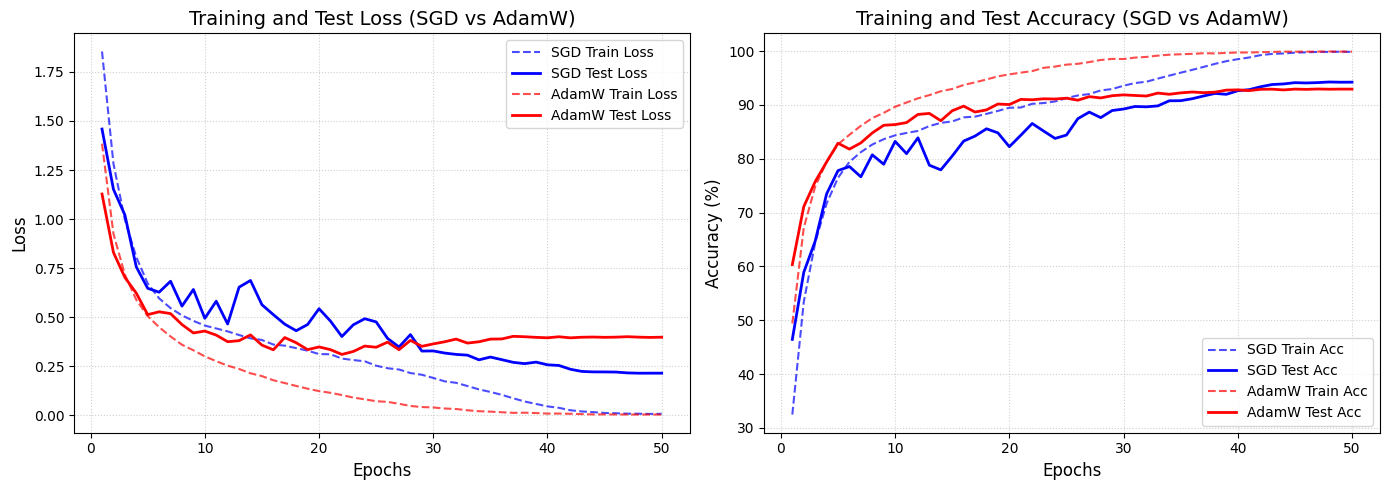

In [ ]:
import matplotlib.pyplot as plt

# 그래프 크기 설정
plt.figure(figsize=(14, 5))

# 에포크 수 (1부터 50까지)
epochs = range(1, len(history_sgd['train_loss']) + 1)

# --- 1. Loss 그래프 ---
plt.subplot(1, 2, 1)
plt.plot(epochs, history_sgd['train_loss'], 'b--', alpha=0.7, label='SGD Train Loss')
plt.plot(epochs, history_sgd['test_loss'], 'b-', linewidth=2, label='SGD Test Loss')
plt.plot(epochs, history_adamw['train_loss'], 'r--', alpha=0.7, label='AdamW Train Loss')
plt.plot(epochs, history_adamw['test_loss'], 'r-', linewidth=2, label='AdamW Test Loss')
plt.title('Training and Test Loss (SGD vs AdamW)', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# --- 2. Accuracy 그래프 ---
plt.subplot(1, 2, 2)
plt.plot(epochs, history_sgd['train_acc'], 'b--', alpha=0.7, label='SGD Train Acc')
plt.plot(epochs, history_sgd['test_acc'], 'b-', linewidth=2, label='SGD Test Acc')
plt.plot(epochs, history_adamw['train_acc'], 'r--', alpha=0.7, label='AdamW Train Acc')
plt.plot(epochs, history_adamw['test_acc'], 'r-', linewidth=2, label='AdamW Test Acc')
plt.title('Training and Test Accuracy (SGD vs AdamW)', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# 출력
plt.tight_layout()
plt.show()

In [ ]:
import time
import torch
import torch.nn as nn
import torch.optim as optim

# ---------------------------------------------------------
# 1. SAM Optimizer 클래스 정의 (PyTorch 표준 구현체 단순화)
# ---------------------------------------------------------
class SAM(torch.optim.Optimizer):
    def __init__(self, params, base_optimizer, rho=0.05, **kwargs):
        defaults = dict(rho=rho, **kwargs)
        super(SAM, self).__init__(params, defaults)
        self.base_optimizer = base_optimizer(self.param_groups, **kwargs)
        self.param_groups = self.base_optimizer.param_groups

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        # 첫 번째 스텝: Loss가 가장 가파른 방향(w + e(w))으로 잠시 이동
        grad_norm = self._grad_norm()
        for group in self.param_groups:
            scale = group["rho"] / (grad_norm + 1e-12)
            for p in group["params"]:
                if p.grad is None: continue
                self.state[p]["old_p"] = p.data.clone() # 원래 위치 저장
                e_w = p.grad * scale.to(p)
                p.add_(e_w) # 가파른 곳으로 이동
        if zero_grad: self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        # 두 번째 스텝: 가파른 곳에서 계산한 기울기를 바탕으로 진짜 업데이트
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None: continue
                p.data = self.state[p]["old_p"] # 다시 원래 위치로 복귀
        self.base_optimizer.step() # SGD 업데이트 진행
        if zero_grad: self.zero_grad()

    @torch.no_grad()
    def _grad_norm(self):
        shared_device = self.param_groups[0]["params"][0].device
        return torch.norm(torch.stack([p.grad.norm(p=2).to(shared_device)
                                       for group in self.param_groups for p in group["params"]
                                       if p.grad is not None]), p=2)

# ---------------------------------------------------------
# 2. SAM 전용 학습 엔진 (Epoch 50)
# ---------------------------------------------------------
def train_sam(num_epochs=50):
    model = get_resnet18_model() # 이전 셀에서 만든 함수 재사용
    criterion = nn.CrossEntropyLoss()

    # SAM은 내부적으로 SGD를 베이스로 사용함
    base_optimizer = optim.SGD
    optimizer = SAM(model.parameters(), base_optimizer, rho=0.05, lr=0.1, momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer.base_optimizer, T_max=num_epochs)

    print(f"\n🔥 [SAM] 학습 시작 (총 {num_epochs} Epoch) - ⏳ 2배의 시간이 소요됩니다! 🔥")
    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

    for epoch in range(num_epochs):
        start_time = time.time()
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # --- SAM 특유의 2-Step 업데이트 과정 ---
            # Step 1. 현재 위치에서 기울기 계산 후 가파른 곳으로 이동
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.first_step(zero_grad=True)

            # Step 2. 가파른 곳에서 다시 기울기 계산 후 실제 업데이트
            criterion(model(images), labels).backward()
            optimizer.second_step(zero_grad=True)
            # --------------------------------------

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

        epoch_train_loss = train_loss / len(train_loader)
        epoch_train_acc = 100. * train_correct / train_total
        scheduler.step()

        # Test 평가 부분
        model.eval()
        test_loss, test_correct, test_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                test_loss += loss.item()
                _, predicted = outputs.max(1)
                test_total += labels.size(0)
                test_correct += predicted.eq(labels).sum().item()

        epoch_test_loss = test_loss / len(test_loader)
        epoch_test_acc = 100. * test_correct / test_total

        history['train_loss'].append(epoch_train_loss)
        history['test_loss'].append(epoch_test_loss)
        history['train_acc'].append(epoch_train_acc)
        history['test_acc'].append(epoch_test_acc)

        elapsed_time = time.time() - start_time
        print(f"Epoch [{epoch+1}/{num_epochs}] | Time: {elapsed_time:.1f}s | "
              f"Train Acc: {epoch_train_acc:.2f}% | Test Acc: {epoch_test_acc:.2f}%")

    torch.save(model.state_dict(), "SAM_best_model.pth")
    return history

# SAM 실행 및 결과 저장
history_sam = train_sam(num_epochs=50)
print("\n✅ SAM 50 Epoch 학습 및 평가 완료!")


🔥 [SAM] 학습 시작 (총 50 Epoch) - ⏳ 2배의 시간이 소요됩니다! 🔥
Epoch [1/50] | Time: 89.3s | Train Acc: 22.65% | Test Acc: 34.14%
Epoch [2/50] | Time: 88.3s | Train Acc: 40.50% | Test Acc: 44.30%
Epoch [3/50] | Time: 88.2s | Train Acc: 52.34% | Test Acc: 58.13%
Epoch [4/50] | Time: 87.4s | Train Acc: 62.11% | Test Acc: 65.85%
Epoch [5/50] | Time: 86.9s | Train Acc: 67.95% | Test Acc: 70.54%
Epoch [6/50] | Time: 86.9s | Train Acc: 72.53% | Test Acc: 71.45%
Epoch [7/50] | Time: 87.0s | Train Acc: 76.59% | Test Acc: 77.82%
Epoch [8/50] | Time: 86.9s | Train Acc: 79.02% | Test Acc: 77.26%
Epoch [9/50] | Time: 86.9s | Train Acc: 81.07% | Test Acc: 74.35%
Epoch [10/50] | Time: 86.8s | Train Acc: 82.34% | Test Acc: 76.77%
Epoch [11/50] | Time: 86.8s | Train Acc: 83.54% | Test Acc: 81.80%
Epoch [12/50] | Time: 86.6s | Train Acc: 84.14% | Test Acc: 82.34%
Epoch [13/50] | Time: 86.6s | Train Acc: 84.89% | Test Acc: 83.53%
Epoch [14/50] | Time: 86.6s | Train Acc: 85.66% | Test Acc: 82.49%
Epoch [15/50] | Time: 

In [ ]:
import pandas as pd
import os

# 에포크 리스트 (1~50)
epochs = range(1, 51)

# 세 가지 옵티마이저의 결과를 하나의 딕셔너리로 묶기
data = {
    'Epoch': epochs,

    # SGD 결과
    'SGD_Train_Loss': history_sgd['train_loss'],
    'SGD_Test_Loss': history_sgd['test_loss'],
    'SGD_Train_Acc': history_sgd['train_acc'],
    'SGD_Test_Acc': history_sgd['test_acc'],

    # AdamW 결과
    'AdamW_Train_Loss': history_adamw['train_loss'],
    'AdamW_Test_Loss': history_adamw['test_loss'],
    'AdamW_Train_Acc': history_adamw['train_acc'],
    'AdamW_Test_Acc': history_adamw['test_acc'],

    # SAM 결과
    'SAM_Train_Loss': history_sam['train_loss'],
    'SAM_Test_Loss': history_sam['test_loss'],
    'SAM_Train_Acc': history_sam['train_acc'],
    'SAM_Test_Acc': history_sam['test_acc']
}

# 딕셔너리를 판다스 데이터프레임(표 형식)으로 변환
df_results = pd.DataFrame(data)

# 구글 드라이브 경로에 CSV 파일로 저장
save_path = '/content/drive/MyDrive/Colab_Data/optimizer_results.csv'
df_results.to_csv(save_path, index=False)

print(f"✅ 생존 완료! 데이터가 성공적으로 저장되었습니다.\n저장 경로: {save_path}")

✅ 생존 완료! 데이터가 성공적으로 저장되었습니다.
저장 경로: /content/drive/MyDrive/Colab_Data/optimizer_results.csv


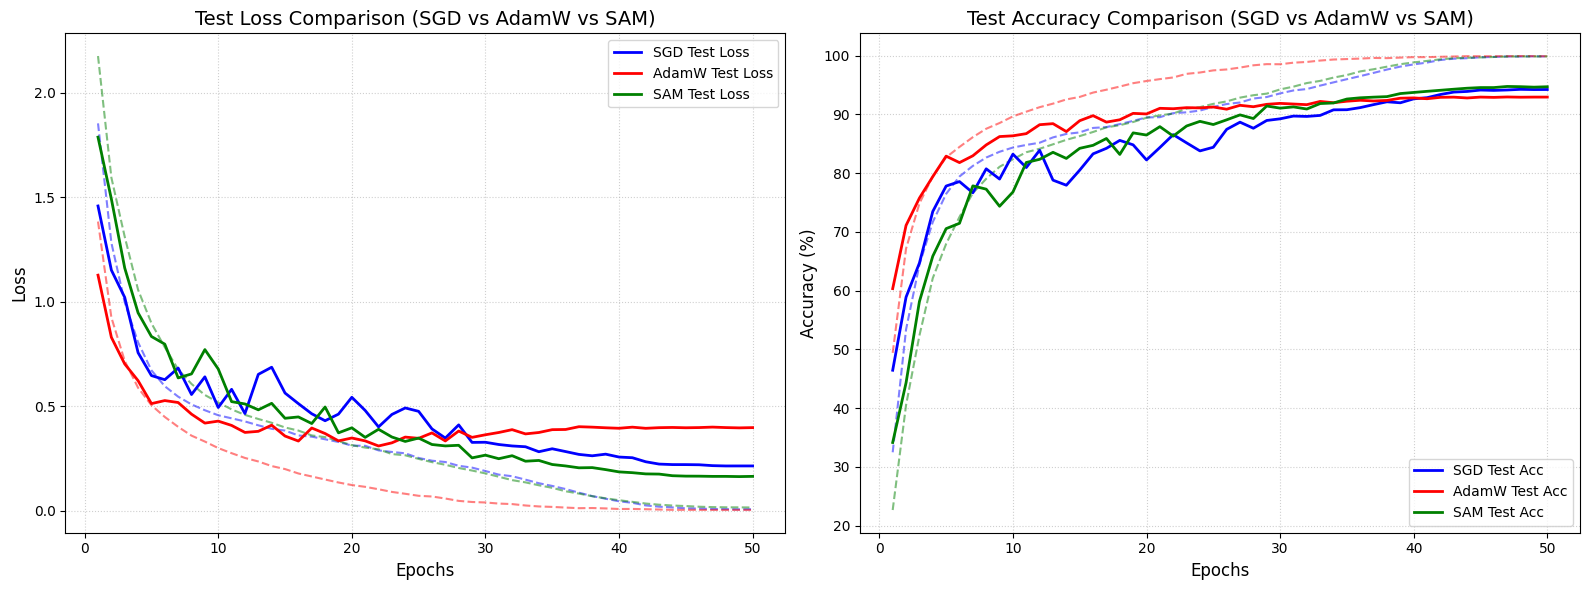

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))
epochs = range(1, 51)

# --- 1. Loss 그래프 ---
plt.subplot(1, 2, 1)
# Train Loss (점선)
plt.plot(epochs, history_sgd['train_loss'], 'b--', alpha=0.5)
plt.plot(epochs, history_adamw['train_loss'], 'r--', alpha=0.5)
plt.plot(epochs, history_sam['train_loss'], 'g--', alpha=0.5)

# Test Loss (실선)
plt.plot(epochs, history_sgd['test_loss'], 'b-', linewidth=2, label='SGD Test Loss')
plt.plot(epochs, history_adamw['test_loss'], 'r-', linewidth=2, label='AdamW Test Loss')
plt.plot(epochs, history_sam['test_loss'], 'g-', linewidth=2, label='SAM Test Loss')

plt.title('Test Loss Comparison (SGD vs AdamW vs SAM)', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# --- 2. Accuracy 그래프 ---
plt.subplot(1, 2, 2)
# Train Acc (점선)
plt.plot(epochs, history_sgd['train_acc'], 'b--', alpha=0.5)
plt.plot(epochs, history_adamw['train_acc'], 'r--', alpha=0.5)
plt.plot(epochs, history_sam['train_acc'], 'g--', alpha=0.5)

# Test Acc (실선) - 우리가 가장 중요하게 봐야 할 지표!
plt.plot(epochs, history_sgd['test_acc'], 'b-', linewidth=2, label='SGD Test Acc')
plt.plot(epochs, history_adamw['test_acc'], 'r-', linewidth=2, label='AdamW Test Acc')
plt.plot(epochs, history_sam['test_acc'], 'g-', linewidth=2, label='SAM Test Acc')

plt.title('Test Accuracy Comparison (SGD vs AdamW vs SAM)', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()